In [8]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split

# 1. Load the arff file
# 'data' contains the record array, 'meta' contains column info
data, meta = arff.loadarff('/kaggle/input/phishing/Training Dataset.arff')

# 2. Convert to a Pandas DataFrame
df = pd.DataFrame(data)

# 2. Clean the data: Decode byte strings to standard text
# This removes the b'...' prefix from categories
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')

# 3. Handle placeholders: Convert '?' to NaN and then to numbers
# This ensures standard null-checking works
df = df.replace([b'?', '?'], np.nan)

# Modern way to convert to numeric without the warning
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Now check for nulls again to see if the conversion created any
print(f"Total NaNs after numeric conversion: {df.isnull().sum().sum()}")

# 4. Verification: Check for Nulls and Feature Count
nan_count = df.isnull().sum().sum()
print(f"Total missing values (NaNs and '?'): {nan_count}")
print(f"Number of features found: {len(df.columns) - 1}") # Minus 1 for the target

# 5. Map Labels to match Andrew Ng Lab (Safe=1 -> 0, Phish=-1 -> 1)
# Assuming 'Result' is the name of your target column
df['Result'] = df['Result'].map({1: 0, -1: 1})

# 6. Split the data (80% Training, 20% Testing)
# We use '36' as our pattern identifier (seed)
X = df.drop(columns=['Result']).values # Features (30 columns)
y = df['Result'].values                # Target (1 column)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=36
)

# 7. Final Output Check
print("--- Setup Complete ---")
print(f"X_train shape: {X_train.shape}") # Should be (m_train, 30)
print(f"y_train first 5 labels: {y_train[:5]}")

Total NaNs after numeric conversion: 0
Total missing values (NaNs and '?'): 0
Number of features found: 30
--- Setup Complete ---
X_train shape: (8844, 30)
y_train first 5 labels: [0 1 0 0 0]


In [9]:
def sigmoid(z):
    """
    Compute the sigmoid of z
    """
    g = 1 / (1 + np.exp(-z))
    return g

In [10]:
def compute_cost(X, y, w, b):
    """
    Computes the cost over all examples
    """
    m = X.shape[0]
    # 1. Get predictions (z = w*x + b)
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    
    # 2. Calculate Loss
    # We add a tiny epsilon (1e-15) to prevent log(0) errors
    loss = -y * np.log(f_wb + 1e-15) - (1 - y) * np.log(1 - f_wb + 1e-15)
    
    total_cost = (1 / m) * np.sum(loss)
    return total_cost

In [11]:
def compute_gradient(X, y, w, b): 
    """
    Computes the gradient for logistic regression 
    """
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    # 1. Calculate the error for all rows at once
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    err = f_wb - y  # Vector of differences
    
    # 2. Calculate gradients using matrix multiplication
    dj_dw = (1 / m) * np.dot(X.T, err)
    dj_db = (1 / m) * np.sum(err)
        
    return dj_db, dj_dw

In [13]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    """
    Performs batch gradient descent to learn w and b.
    """
    # Create copies to avoid modifying the original inputs
    w = w_in
    b = b_in
    
    # Optional: list to store cost history (to see if the model is learning)
    j_history = []

    for i in range(num_iters):
        # 1. Calculate the gradient (The direction to move)
        dj_db, dj_dw = compute_gradient(X, y, w, b)   

        # 2. Update Parameters (The "Learning" step)
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # 3. Save cost every few iterations to monitor progress
        if i < 100000:      # prevent resource exhaustion
            j_history.append(compute_cost(X, y, w, b))

        # 4. Print progress every 10% of the way
        if i % (num_iters // 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")
        
    return w, b, j_history

In [14]:
# 1. Initialize variables
# w must have 30 elements because you have 30 features
initial_w = np.zeros(X_train.shape[1]) 
initial_b = 0.

# 2. Set Hyperparameters
# Alpha is the step size; num_iters is how many times it looks at the data
alpha = 0.1
num_iters = 1000

# 3. Run Gradient Descent
w_final, b_final, j_history = gradient_descent(X_train, y_train, initial_w, initial_b, alpha, num_iters)

print("\n--- Training Complete ---")
print(f"Final Weights (first 5): {w_final[:5]}")
print(f"Final Bias: {b_final:.4f}")

Iteration    0: Cost     0.66
Iteration  100: Cost     0.25
Iteration  200: Cost     0.22
Iteration  300: Cost     0.21
Iteration  400: Cost     0.20
Iteration  500: Cost     0.20
Iteration  600: Cost     0.19
Iteration  700: Cost     0.19
Iteration  800: Cost     0.19
Iteration  900: Cost     0.19

--- Training Complete ---
Final Weights (first 5): [-0.51686393  0.16410615  0.27105632 -0.28921447 -0.09419687]
Final Bias: -0.2451


In [15]:
def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w and b
    """
    m = X.shape[0]
    p = np.zeros(m)
   
    # Calculate probabilities using your final weights
    z = np.dot(X, w) + b
    prob = sigmoid(z)

    # Convert probabilities to 0 or 1
    # This is like a Java 'if (prob >= 0.5) return 1; else return 0;'
    p = (prob >= 0.5).astype(int)
        
    return p

In [16]:
# Get predictions for the test set
test_predictions = predict(X_test, w_final, b_final)

# Calculate accuracy percentage
# np.mean(test_predictions == y_test) checks how many match
accuracy = np.mean(test_predictions == y_test) * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 92.45%


Final Test Accuracy: 92.45%

--- Top 10 Phishing Indicators ---
                   Feature    Weight
13           URL_of_Anchor -2.411100
7           SSLfinal_State -1.567007
5            Prefix_Suffix -1.042699
25             web_traffic -0.721203
15                     SFH -0.686219
14           Links_in_tags -0.682988
28  Links_pointing_to_page -0.613323
6        having_Sub_Domain -0.576898
27            Google_Index -0.527518
0        having_IP_Address -0.516864


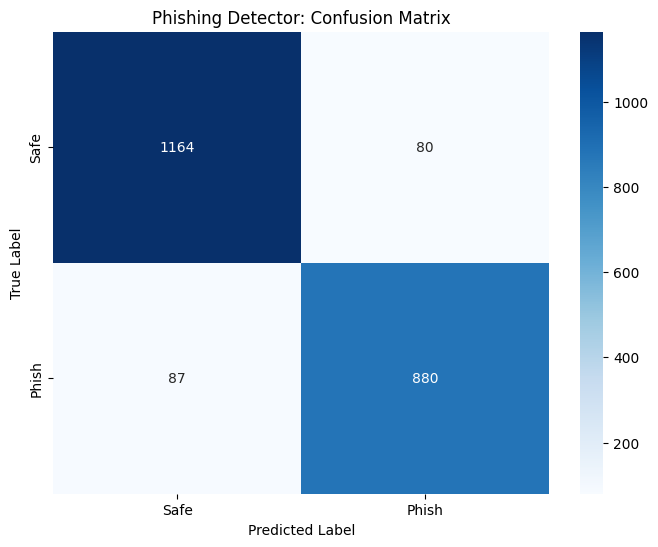


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Safe       0.93      0.94      0.93      1244
       Phish       0.92      0.91      0.91       967

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate Predictions for the Test set
# (This fixes the NameError you saw earlier)
p_test = predict(X_test, w_final, b_final)

# 2. Accuracy Calculation
test_acc = np.mean(p_test == y_test) * 100
print(f"Final Test Accuracy: {test_acc:.2f}%")

# 3. Feature Importance (The "Red Flags")
# Let's see which of the 30 features have the highest weights
feature_names = df.drop(columns=['Result']).columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Weight': w_final})

# Sort by the influence (Absolute Weight)
feature_importance['Influence'] = feature_importance['Weight'].abs()
top_10 = feature_importance.sort_values(by='Influence', ascending=False).head(10)

print("\n--- Top 10 Phishing Indicators ---")
print(top_10[['Feature', 'Weight']])

# 4. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, p_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Phish'], 
            yticklabels=['Safe', 'Phish'])
plt.title('Phishing Detector: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Final Statistics (Precision and Recall)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, p_test, target_names=['Safe', 'Phish']))